PROJET 3 - Prédiction du Churn Client
Notebook 01 : Exploration et Préparation des Données
Cellule 1 - Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Librairies chargées avec succès")

Librairies chargées avec succès


Cellule 2 - Chargement des données

In [2]:
# Chargement du dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 7043 lignes x 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cellule 3 - Analyse de la structure

In [3]:
# Types de données et valeurs non-nulles
print("=== INFORMATIONS GÉNÉRALES ===")
print(df.info())

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043

Cellule 4 - Statistiques descriptives 

In [4]:
# Aperçu statistique des variables numériques
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== STATISTIQUES DESCRIPTIVES ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Cellule 5 - Analyse de la qualité des données

In [6]:
# Valeurs manquantes
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_df[missing_df['Valeurs manquantes'] > 0])
print(f"\nAucune valeur manquante détectée" if missing.sum() == 0 else "")

# Doublons
print(f"\n=== DOUBLONS ===")
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

# Valeurs uniques par colonne
print(f"\n=== VALEURS UNIQUES PAR COLONNE ===")
for col in df.columns:
    print(f"{col:25s} : {df[col].nunique()} valeurs uniques")

=== VALEURS MANQUANTES ===
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage (%)]
Index: []

Aucune valeur manquante détectée

=== DOUBLONS ===
Nombre de lignes dupliquées : 0

=== VALEURS UNIQUES PAR COLONNE ===
customerID                : 7043 valeurs uniques
gender                    : 2 valeurs uniques
SeniorCitizen             : 2 valeurs uniques
Partner                   : 2 valeurs uniques
Dependents                : 2 valeurs uniques
tenure                    : 73 valeurs uniques
PhoneService              : 2 valeurs uniques
MultipleLines             : 3 valeurs uniques
InternetService           : 3 valeurs uniques
OnlineSecurity            : 3 valeurs uniques
OnlineBackup              : 3 valeurs uniques
DeviceProtection          : 3 valeurs uniques
TechSupport               : 3 valeurs uniques
StreamingTV               : 3 valeurs uniques
StreamingMovies           : 3 valeurs uniques
Contract                  : 3 valeurs uniques
PaperlessBilling          : 2 valeurs u

Cellule 6 - Correction de TotalCharges

In [7]:
# TotalCharges contient des espaces vides au lieu de NaN
# On force la conversion en numérique (les espaces deviennent NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Vérification : combien de NaN sont apparus ?
print(f"Valeurs NaN dans TotalCharges après conversion : {df['TotalCharges'].isnull().sum()}")

# Afficher les lignes concernées
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Valeurs NaN dans TotalCharges après conversion : 11
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


Cellule 7 - Interprétation et traitement des NaN

In [8]:
# Ces clients ont un tenure de 0 (tout nouveaux clients, pas encore facturés)
# Logique : TotalCharges = 0 pour tenure = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Valeurs NaN restantes : {df['TotalCharges'].isnull().sum()}")
print(f"Type de TotalCharges : {df['TotalCharges'].dtype}")

Valeurs NaN restantes : 0
Type de TotalCharges : float64


Cellule 8 - Harmonisation de SeniorCitizen

In [9]:
# SeniorCitizen est 0/1, on le convertit en Yes/No pour cohérence
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("SeniorCitizen après conversion :")
print(df['SeniorCitizen'].value_counts())

SeniorCitizen après conversion :
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


Cellule 9 - Suppression de customerID

In [10]:
# customerID est un identifiant sans valeur prédictive
df = df.drop(columns=['customerID'])

print(f"Dimensions après nettoyage : {df.shape}")
print(f"Colonnes restantes : {list(df.columns)}")

Dimensions après nettoyage : (7043, 20)
Colonnes restantes : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Cellule 10 - Distribution de la variable cible

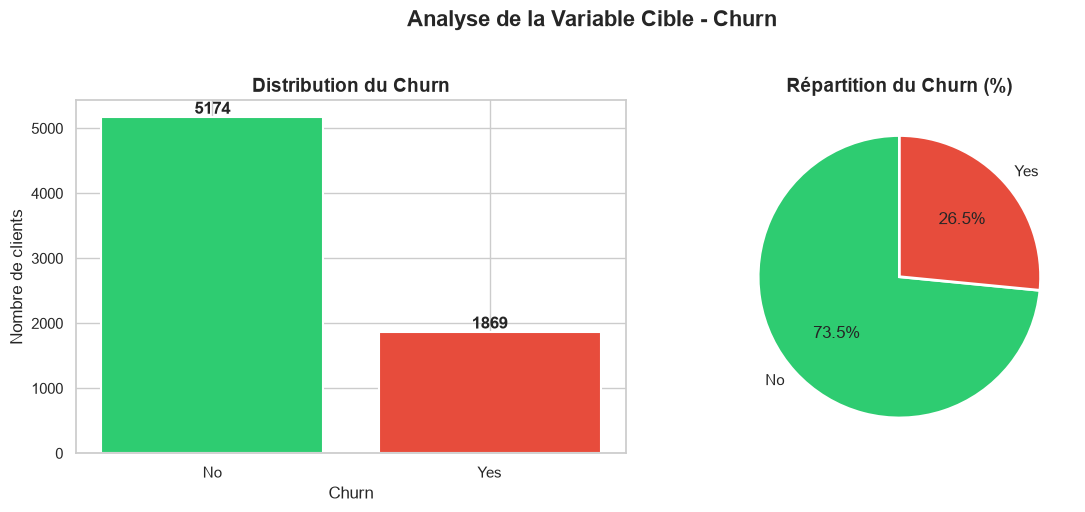


Taux de churn : 26.5%
Clients retenus : 5174 | Clients perdus : 1869


In [11]:
# La variable cible : Churn (Yes = client parti, No = client resté)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comptage
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Barplot
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution du Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Camembert
axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Répartition du Churn (%)', fontsize=14, fontweight='bold')

plt.suptitle('Analyse de la Variable Cible - Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../exports/01_distribution_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTaux de churn : {(churn_counts['Yes'] / len(df) * 100):.1f}%")
print(f"Clients retenus : {churn_counts['No']} | Clients perdus : {churn_counts['Yes']}")

Cellule 11 - Variables démographiques vs Churn

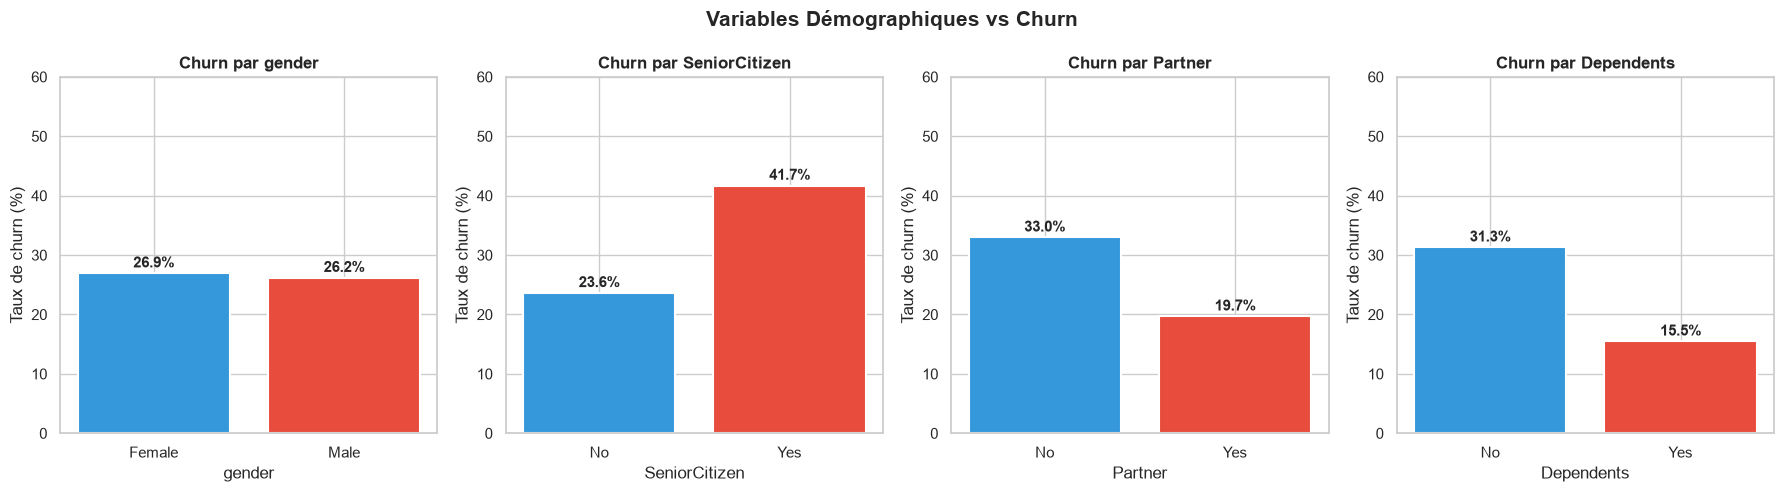

In [12]:
# Impact des variables démographiques sur le churn
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Taux de churn (%)']

    bars = axes[i].bar(
        churn_rate[col],
        churn_rate['Taux de churn (%)'],
        color=['#3498db', '#e74c3c'],
        edgecolor='white',
        linewidth=1.5
    )
    axes[i].set_title(f'Churn par {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].set_ylim(0, 60)
    for bar, val in zip(bars, churn_rate['Taux de churn (%)']):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=11
        )

plt.suptitle('Variables Démographiques vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/02_demographiques_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Cellule 12 - Type de contrat et ancienneté vs Churn

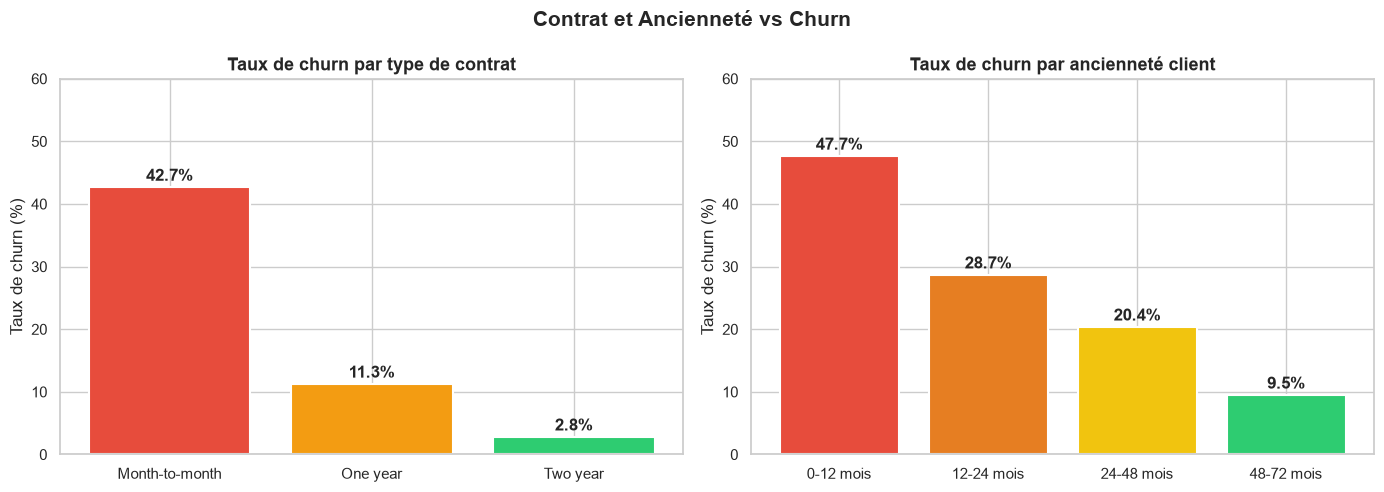

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contrat vs Churn
churn_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
churn_contract.columns = ['Contract', 'Taux de churn (%)']

bars = axes[0].bar(
    churn_contract['Contract'],
    churn_contract['Taux de churn (%)'],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Taux de churn par type de contrat', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taux de churn (%)')
axes[0].set_ylim(0, 60)
for bar, val in zip(bars, churn_contract['Taux de churn (%)']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center', fontweight='bold'
    )

# Tenure vs Churn (boxplot)
df_box = df.copy()
df_box['tenure_group'] = pd.cut(
    df_box['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 mois', '12-24 mois', '24-48 mois', '48-72 mois']
)
churn_tenure = df_box.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
churn_tenure.columns = ['Ancienneté', 'Taux de churn (%)']

axes[1].bar(
    churn_tenure['Ancienneté'].astype(str),
    churn_tenure['Taux de churn (%)'],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title("Taux de churn par ancienneté client", fontsize=13, fontweight='bold')
axes[1].set_ylabel('Taux de churn (%)')
axes[1].set_ylim(0, 60)
for i, val in enumerate(churn_tenure['Taux de churn (%)']):
    axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Contrat et Ancienneté vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/03_contrat_anciennete_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Cellule 13 - Services souscrits vs Churn

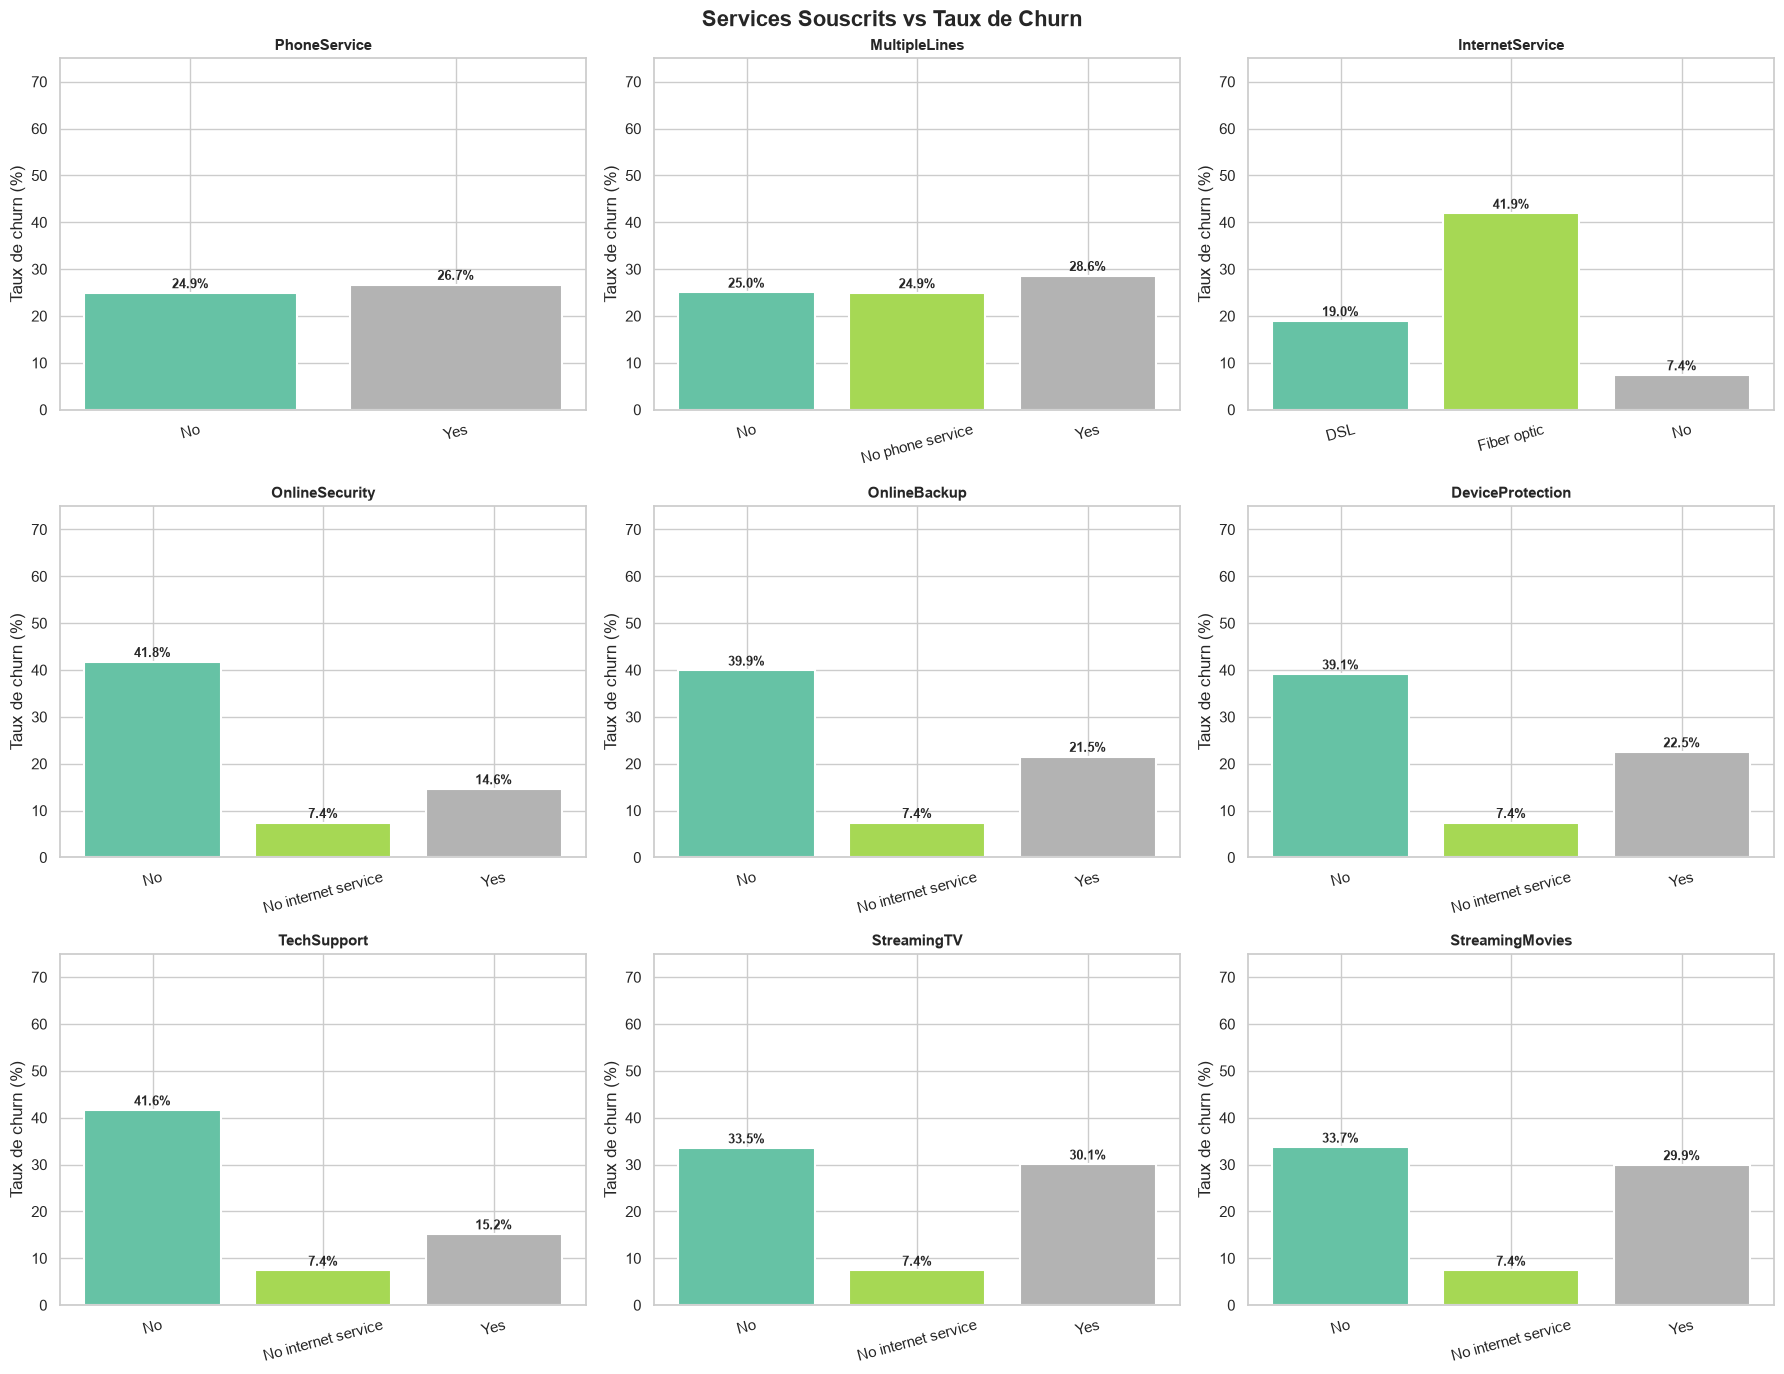

In [14]:
# Impact des services sur le churn
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Taux de churn (%)']

    colors_bar = plt.cm.Set2(np.linspace(0, 1, len(churn_rate)))
    bars = axes[i].bar(
        churn_rate[col],
        churn_rate['Taux de churn (%)'],
        color=colors_bar,
        edgecolor='white',
        linewidth=1.5
    )
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].set_ylim(0, 75)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate['Taux de churn (%)']):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold'
        )

plt.suptitle('Services Souscrits vs Taux de Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/04_services_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Cellule 14 - Variables numériques vs Churn

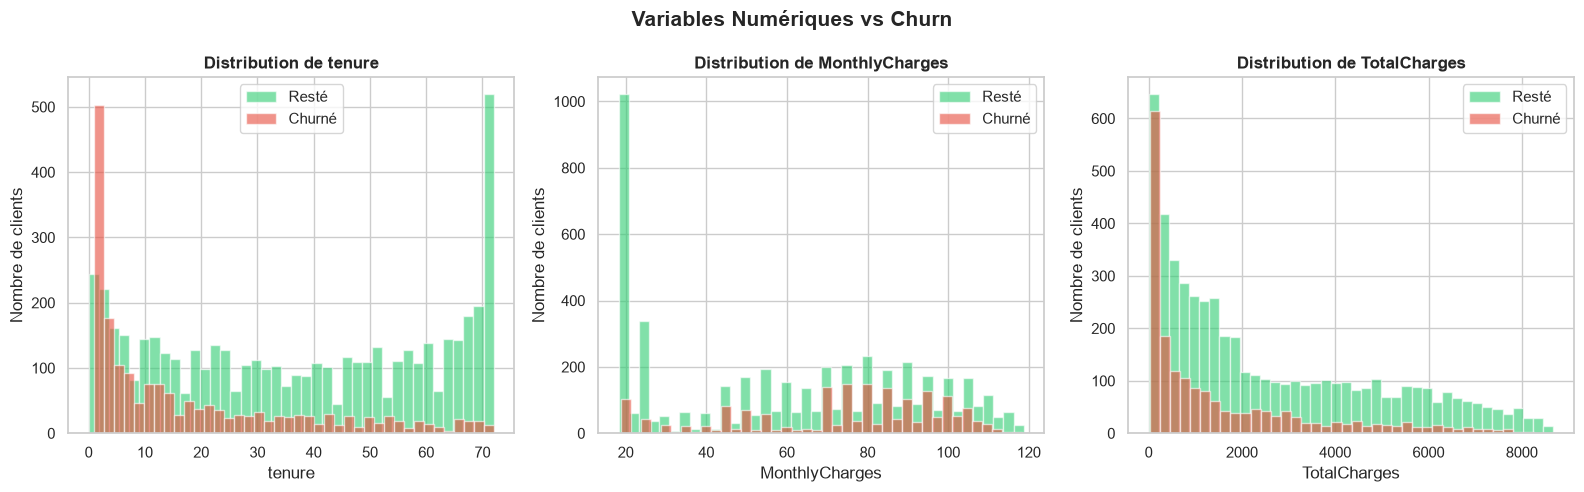

In [15]:
# Distribution des variables numériques selon le churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    for churn_val, color, label in zip(
        ['No', 'Yes'],
        ['#2ecc71', '#e74c3c'],
        ['Resté', 'Churné']
    ):
        axes[i].hist(
            df[df['Churn'] == churn_val][col],
            bins=40,
            alpha=0.6,
            color=color,
            label=label,
            edgecolor='white'
        )
    axes[i].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].legend()

plt.suptitle('Variables Numériques vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/05_numeriques_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Cellule 15 - Matrice de corrélation

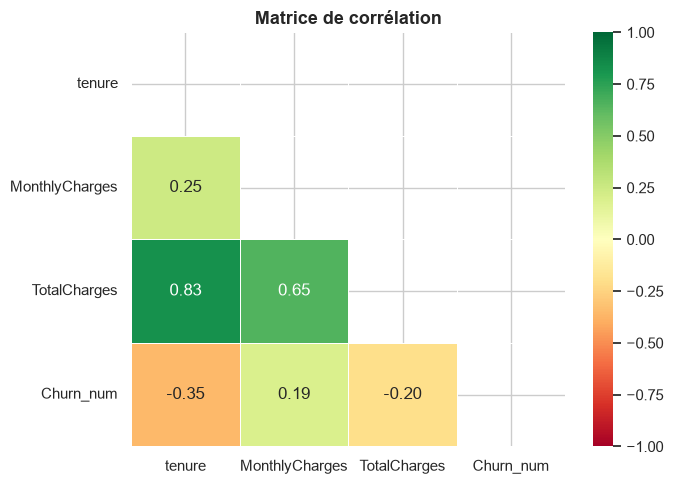

In [16]:
# Corrélation entre variables numériques
# On encode temporairement Churn pour l'inclure
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    ax=ax,
    linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Cellule 16 - Résumé des observations EDA

In [17]:
# ============================================================
# RÉSUMÉ DES OBSERVATIONS EDA
# ============================================================
print("""
OBSERVATIONS CLÉS :

1. DÉSÉQUILIBRE DES CLASSES
   - 73.5% clients retenus vs 26.5% churné
   - On utilisera class_weight='balanced' lors de la modélisation

2. VARIABLES DÉMOGRAPHIQUES
   - Le genre n'influence pas significativement le churn
   - Les seniors churne davantage
   - Les clients sans partenaire ni dépendants churne plus

3. CONTRAT ET ANCIENNETÉ
   - Les contrats Month-to-month ont le taux de churn le plus élevé
   - Les nouveaux clients (0-12 mois) sont les plus à risque
   - Plus un client est ancien, moins il churne

4. SERVICES
   - Fiber optic : taux de churn très élevé
   - Absence de OnlineSecurity et TechSupport : facteur de risque
   - Les services de streaming n'ont pas d'effet protecteur notable

5. VARIABLES NUMÉRIQUES
   - MonthlyCharges élevées corrélées au churn
   - TotalCharges faibles (nouveaux clients) corrélées au churn
   - tenure faible = risque de churn élevé
""")


OBSERVATIONS CLÉS :

1. DÉSÉQUILIBRE DES CLASSES
   - 73.5% clients retenus vs 26.5% churné
   - On utilisera class_weight='balanced' lors de la modélisation

2. VARIABLES DÉMOGRAPHIQUES
   - Le genre n'influence pas significativement le churn
   - Les seniors churne davantage
   - Les clients sans partenaire ni dépendants churne plus

3. CONTRAT ET ANCIENNETÉ
   - Les contrats Month-to-month ont le taux de churn le plus élevé
   - Les nouveaux clients (0-12 mois) sont les plus à risque
   - Plus un client est ancien, moins il churne

4. SERVICES
   - Fiber optic : taux de churn très élevé
   - Absence de OnlineSecurity et TechSupport : facteur de risque
   - Les services de streaming n'ont pas d'effet protecteur notable

5. VARIABLES NUMÉRIQUES
   - MonthlyCharges élevées corrélées au churn
   - TotalCharges faibles (nouveaux clients) corrélées au churn
   - tenure faible = risque de churn élevé



Cellule 17 - Nettoyage final et export

In [18]:
# ============================================================
# PRÉPARATION DU DATASET PROPRE POUR LA MODÉLISATION
# ============================================================

df_clean = df.copy()

# Vérification finale
print("=== DATASET FINAL ===")
print(f"Dimensions : {df_clean.shape}")
print(f"\nTypes de données :")
print(df_clean.dtypes)
print(f"\nValeurs manquantes : {df_clean.isnull().sum().sum()}")
print(f"\nDistribution cible :")
print(df_clean['Churn'].value_counts())

# Export du dataset nettoyé
df_clean.to_csv('../exports/dataset_clean.csv', index=False)
print("\nDataset propre exporté dans exports/dataset_clean.csv")

=== DATASET FINAL ===
Dimensions : (7043, 20)

Types de données :
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Valeurs manquantes : 0

Distribution cible :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Dataset propre exporté dans exports/dataset_clean.csv


Cellule 18 - Rapport de qualité des données

In [19]:
# ============================================================
# RAPPORT DE QUALITÉ DES DONNÉES
# ============================================================

print("=== RAPPORT DE QUALITÉ DES DONNÉES ===\n")

# Colonnes numériques
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Colonnes catégorielles
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numériques ({len(num_cols)}) : {num_cols}")
print(f"Variables catégorielles ({len(cat_cols)}) : {cat_cols}")

print("\n--- Statistiques variables numériques ---")
print(df_clean[num_cols].describe().round(2))

print("\n--- Modalités variables catégorielles ---")
for col in cat_cols:
    print(f"\n{col} :")
    print(df_clean[col].value_counts().to_string())

=== RAPPORT DE QUALITÉ DES DONNÉES ===

Variables numériques (3) : ['tenure', 'MonthlyCharges', 'TotalCharges']
Variables catégorielles (17) : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

--- Statistiques variables numériques ---
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

--- Modalités variables catégorielles ---

gender :
gender
Male      3555
Female    3488

SeniorCitizen :
SeniorCitizen
No     5901
Yes    114

Cellule 19 - Conclusion du notebook

In [20]:
print("""
============================================================
NOTEBOOK 01 - TERMINÉ
============================================================

Fichiers générés dans exports/ :
  - 01_distribution_churn.png
  - 02_demographiques_churn.png
  - 03_contrat_anciennete_churn.png
  - 04_services_churn.png
  - 05_numeriques_churn.png
  - 06_correlation.png
  - dataset_clean.csv

Prochaine étape : Notebook 02 - Modélisation et Validation
============================================================
""")


NOTEBOOK 01 - TERMINÉ

Fichiers générés dans exports/ :
  - 01_distribution_churn.png
  - 02_demographiques_churn.png
  - 03_contrat_anciennete_churn.png
  - 04_services_churn.png
  - 05_numeriques_churn.png
  - 06_correlation.png
  - dataset_clean.csv

Prochaine étape : Notebook 02 - Modélisation et Validation

